# 02 — Preprocessing Pipeline

In notebook 01 we observed the raw signal and identified specific contaminants
that have to be addressed before any classifier sees this data:

| Observation (nb 01)            | Problem                                | Stage that fixes it      |
|--------------------------------|----------------------------------------|--------------------------|
| Sharp PSD spike at 60 Hz        | US mains line noise                    | Notch filter             |
| 1/f-shaped low-frequency rise   | Slow drift, sweat, electrode polarization | High-pass filter at 1 Hz |
| Broadband HF power on temporals | Muscle (EMG) contamination             | Low-pass at 40 Hz + ICA  |
| Large slow deflections on Fp1/Fp2 | Eye blinks and saccades              | ICA                      |
| Gamma topomap dominated by edges | Muscle, not neural gamma              | Low-pass + ICA           |
| (Possible) flat/noisy channels  | Bad electrode contact                  | Bad-channel detection    |

This notebook walks the pipeline implemented in `src/preprocessing.py` one
function at a time, visualizing what each stage removes or changes. By the
end we have cleaned, epoched data saved as `.fif` for notebook 03 to consume.

**Pipeline order matters.** Filtering before ICA stabilizes the decomposition.
Bad-channel detection before re-referencing prevents bad channels from
poisoning the common average. ICA on continuous data before epoching
preserves more samples for the decomposition. AutoReject *after* epoching
catches residual transients ICA missed.

## Load Raw Data

We load runs 4, 8, and 12 (imagined left vs right fist) for subject 1, the
same subset we explored in notebook 01. The loader standardizes channel
names (the raw EDFs use names like `Fc5.` with trailing dots — a quirk of the
BCI2000 export format) and applies the `standard_1005` montage so MNE knows
the 3D position of each electrode. Without correct positions, topomaps lie
and ICA has no spatial prior.

In [11]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Make src importable from the notebooks/ directory
sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import matplotlib.pyplot as plt
import mne

import preprocessing as pp  # our module

mne.set_log_level("WARNING")  # quiet MNE's chatty default
plt.rcParams["figure.dpi"] = 100

SUBJECT = 1
RUNS = (4, 8, 12)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Channels: 64, Duration: 375.0s, Sampling rate: 160.0 Hz
First few channel names: ['FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4']


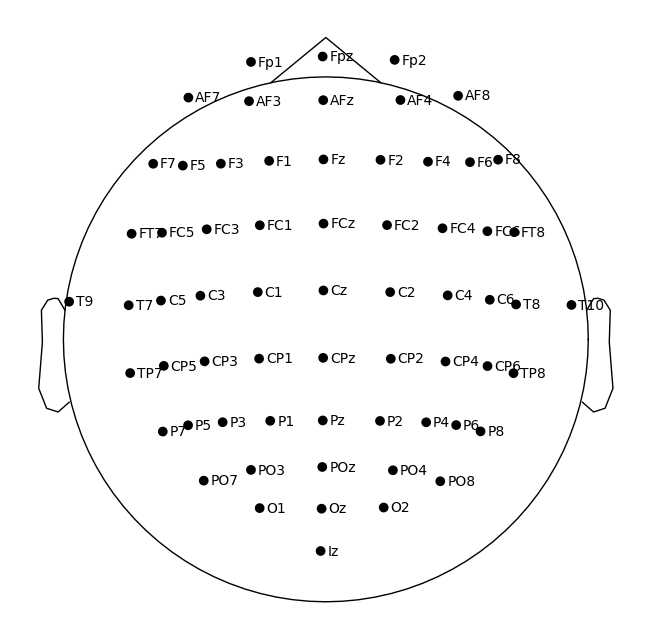

In [16]:
raw = pp.load_subject(SUBJECT, runs=RUNS)

print(f"Channels: {len(raw.ch_names)}, "
      f"Duration: {raw.times[-1]:.1f}s, "
      f"Sampling rate: {raw.info['sfreq']} Hz")
print(f"First few channel names: {raw.ch_names[:6]}")
raw.plot_sensors(show_names=True);

## Filtering (Bandpass + Notch)

**Highpass at 1 Hz**: removes slow drift and is the empirically-validated
cutoff for stable ICA (Winkler et al. 2015). Motor imagery lives in mu
(8–13 Hz) and beta (13–30 Hz), so we lose nothing relevant.

**Lowpass at 40 Hz**: cuts most EMG contamination, which dominates above
~40 Hz. We deliberately sacrifice gamma — notebook 01 showed the gamma
topomap was driven by peripheral muscle anyway.

**Notch at 60 and 120 Hz**: US mains and first harmonic. The 60 Hz peak
was clearly visible in the notebook 01 PSD. 120 Hz is above our lowpass in
principle but notching is cheap and adds a safety margin.

We'll compare PSDs before and after to confirm each effect.

C:\Users\Asus\AppData\Local\Temp\ipykernel_15816\275132248.py:8: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


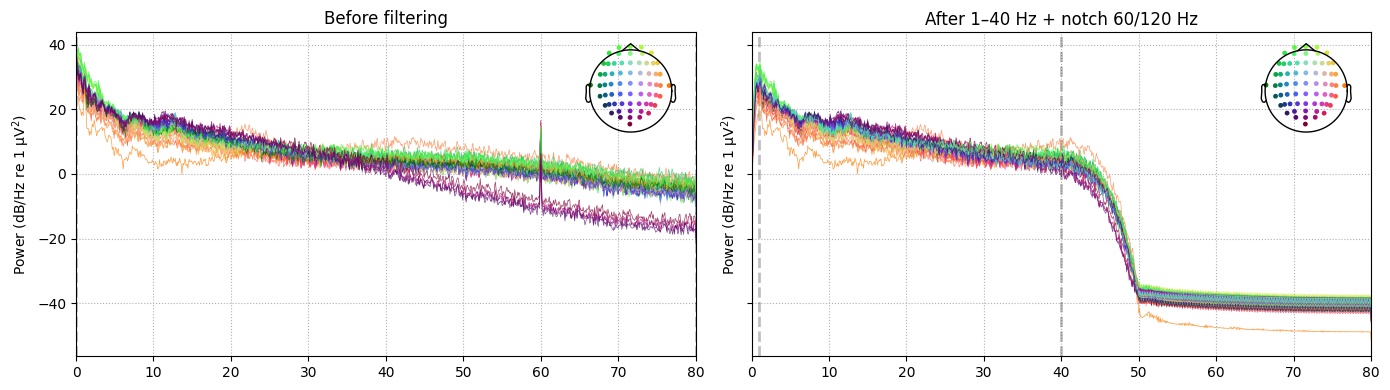

In [19]:
raw_filt = pp.apply_filters(raw)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
raw.compute_psd(fmax=80).plot(axes=axes[0], show=False)
axes[0].set_title("Before filtering")
raw_filt.compute_psd(fmax=80).plot(axes=axes[1], show=False)
axes[1].set_title("After 1–40 Hz + notch 60/120 Hz")
plt.tight_layout()

## Detect bad channels

Bad channels — flat (disconnected), noisy (high variance), or uncorrelated
with their neighbors (bridging, bad contact) — must be identified *before*
we re-reference. The common average reference subtracts the mean across
channels; if a flat or noisy channel is included in the average, its
pathology contaminates every remaining channel.

We use a statistical approach for the single-subject case:
- **Flat**: standard deviation below 1 µV (likely a disconnected electrode)
- **High variance**: log-variance z-score above 3 (outlier noise)
- **Low neighbor correlation**: max correlation with any other channel
  below 0.4 (isolated or bridged)

For the full 109-subject run we'll switch to `pyprep`'s `NoisyChannels`,
which adds RANSAC-based detection — more robust but slower.

Flagged bad channels: []
raw.info['bads'] now contains: []


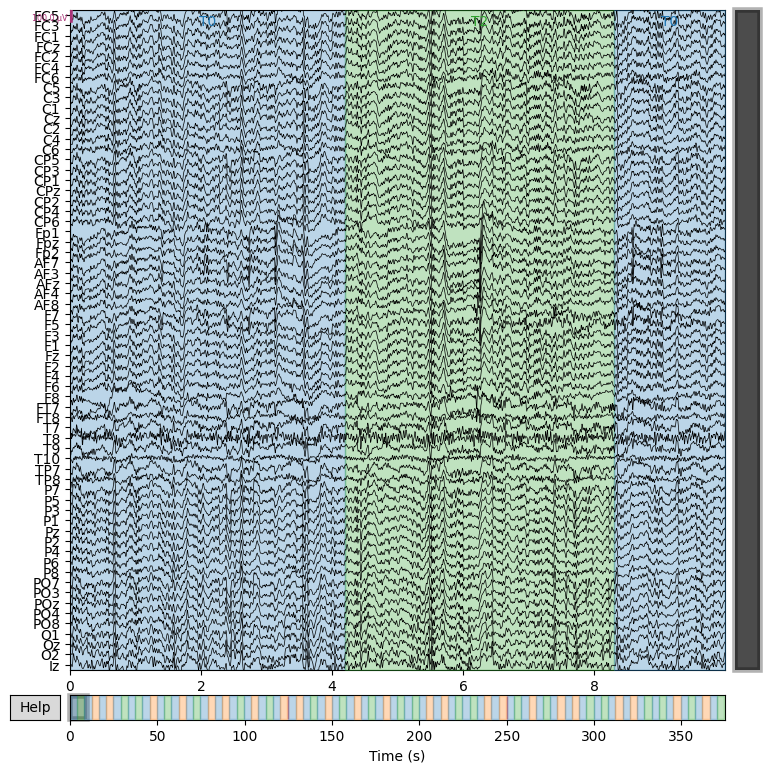

In [20]:
bads = pp.detect_bad_channels(raw_filt, method="statistical")
print(f"Flagged bad channels: {bads}")
print(f"raw.info['bads'] now contains: {raw_filt.info['bads']}")

# Visualize: plot raw with bads highlighted in red
raw_filt.plot(n_channels=len(raw_filt.ch_names),
              duration=10, scalings=dict(eeg=50e-6),
              bad_color="red", show=True);

Note: Subject 1 has no bad channels under our criteria — good news, but the detection logic will matter for the multi-subject run.

## Re-referencing

The PhysioNet recordings use a non-EEG physical reference, which means
every channel carries a common reference signal. Re-referencing to the
average across channels (CAR) approximates a reference-free view and is the
standard pre-ICA reference for sensor-space BCI work.

CAR (Common Average Reference) is applied *after* bad-channel detection so bads are excluded from the
mean.

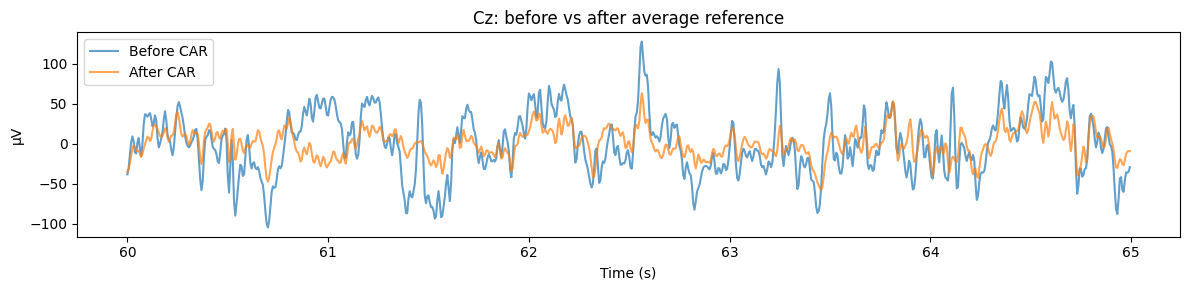

In [21]:
raw_ref = pp.set_reference(raw_filt)

# Pick a central channel and overlay before/after on a short window
ch = "Cz"
start, stop = raw_filt.time_as_index([60, 65])  # 5-second window

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(raw_filt.times[start:stop],
        raw_filt.get_data(picks=ch)[0, start:stop] * 1e6,
        label="Before CAR", alpha=0.7)
ax.plot(raw_ref.times[start:stop],
        raw_ref.get_data(picks=ch)[0, start:stop] * 1e6,
        label="After CAR", alpha=0.7)
ax.set(xlabel="Time (s)", ylabel="µV", title=f"{ch}: before vs after average reference")
ax.legend(); plt.tight_layout()

## ICA Decomposition — Fit ICA

ICA decomposes the multichannel signal into statistically independent
sources. Some of those sources are neural; others are stereotyped artifacts
(blinks, saccades, heartbeat, muscle) with characteristic spatial and
temporal signatures. We fit 20 components — enough to cleanly separate the
common artifact types from neural sources, well below the rank ceiling of
~63 (64 channels minus 1 for CAR).

We use **Picard** as the algorithm: faster than Infomax/FastICA with
equivalent solutions, and MNE's recommended default.

`random_state=97` is pinned so the decomposition is reproducible across
runs of the notebook.

<ICA | raw data decomposition, method: picard (fit in 56 iterations on 60000 samples), 20 ICA components (64 PCA components available), channel types: eeg, no sources marked for exclusion>


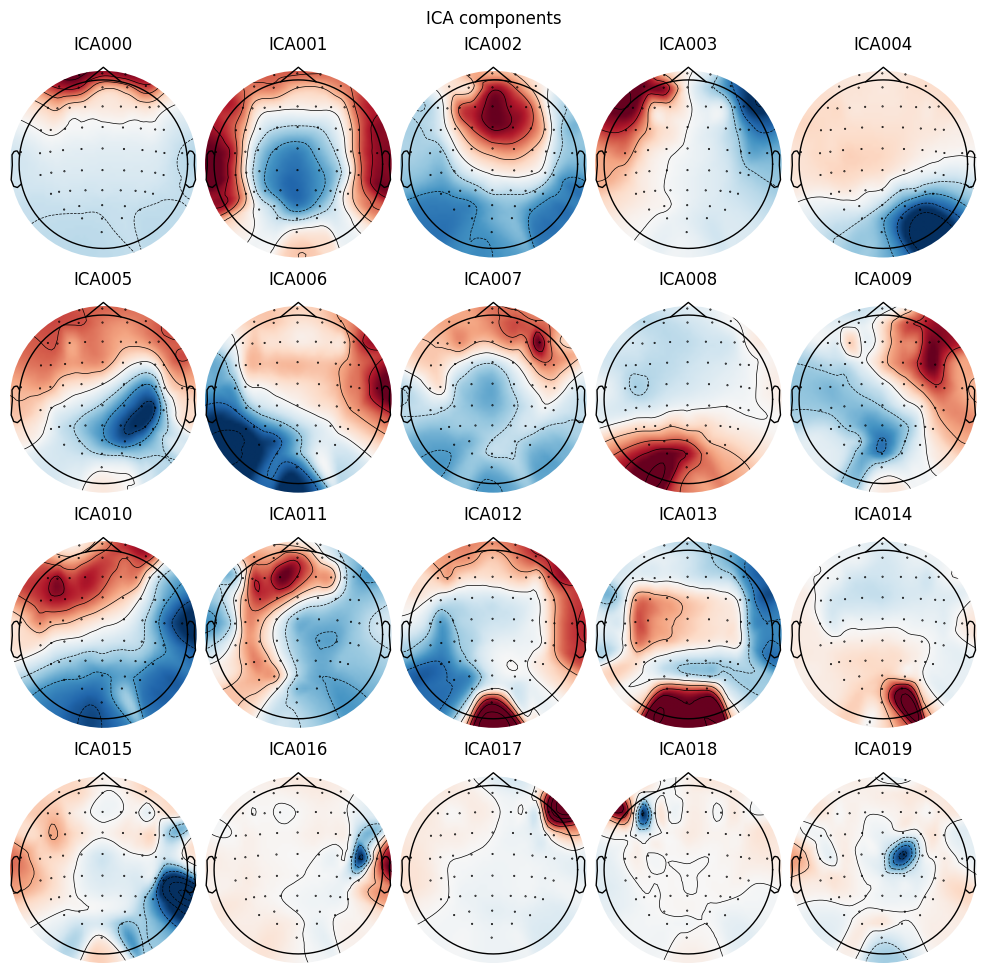

In [23]:
ica = pp.run_ica(raw_ref, n_components=20)
print(ica)

# Topomaps of all components — spatial signatures
ica.plot_components();

## ICA Decomposition — Identify and remove artifact components

This dataset has no dedicated EOG channel. We use **Fp1 as a pseudo-EOG**:
it sits directly above the left eye and picks up both vertical (blink) and
some horizontal (saccade) eye movements. MNE's `find_bads_eog` correlates
each ICA component's time course with Fp1 and flags components with
z-scored correlation above 3.

For muscle, `find_bads_muscle` scores components by their high-frequency
power profile and spatial peripherality — both characteristic of EMG.

We'll plot the flagged components' topographies and properties so the
decision is auditable, not magic.

EOG components flagged: [np.int64(0)]
Muscle components flagged: [15, 16, 17, 18]
Total to exclude: [np.int64(0), 15, 16, 17, 18]


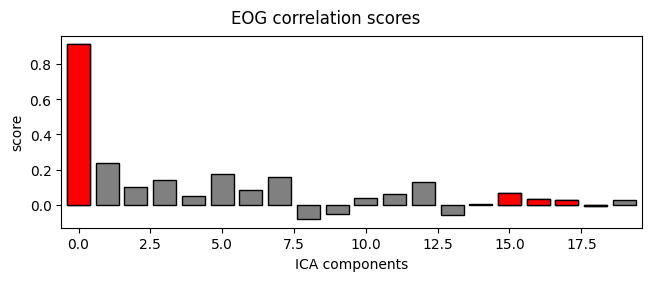

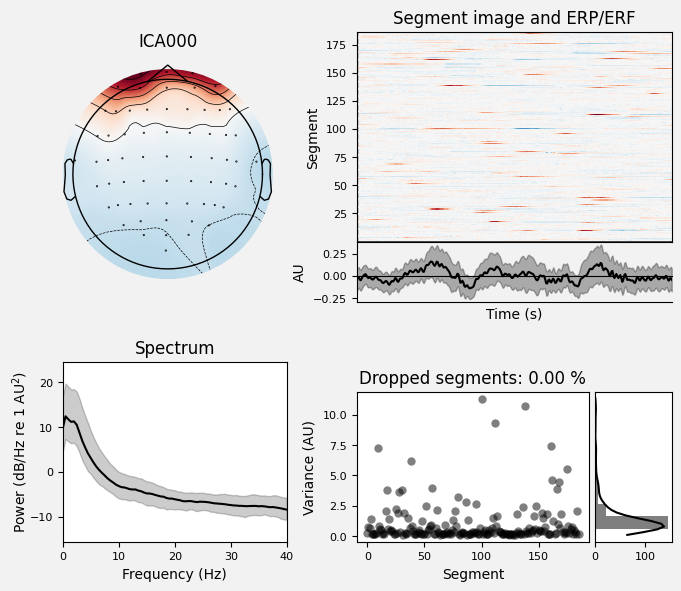

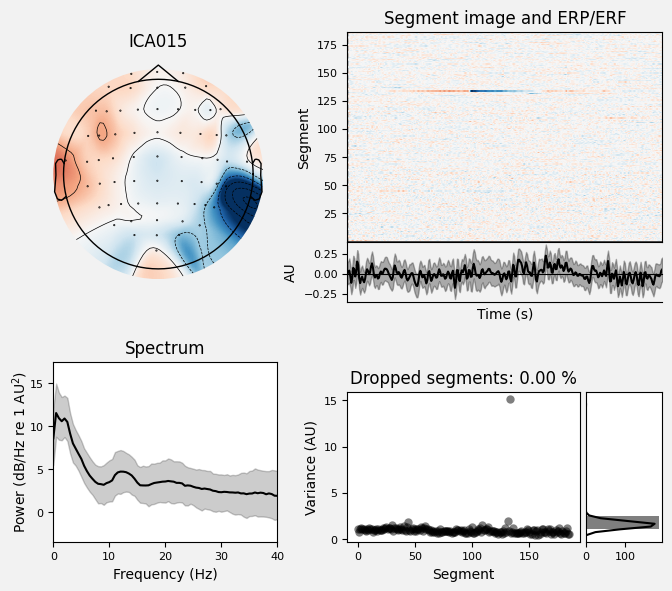

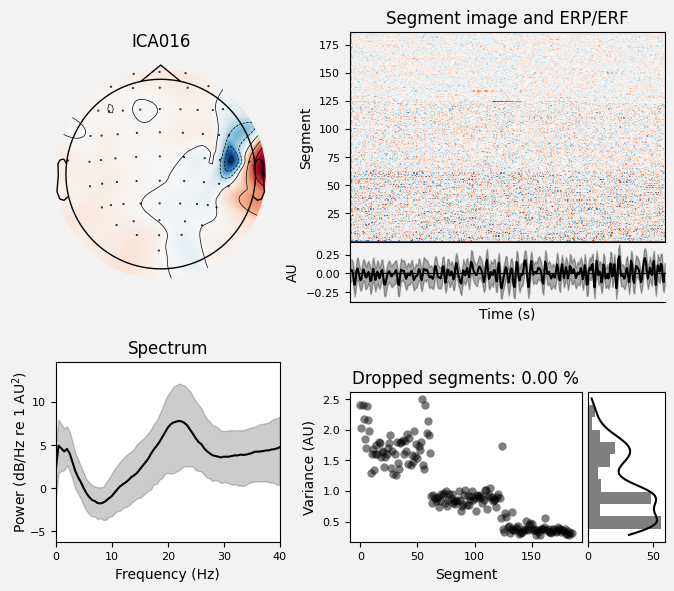

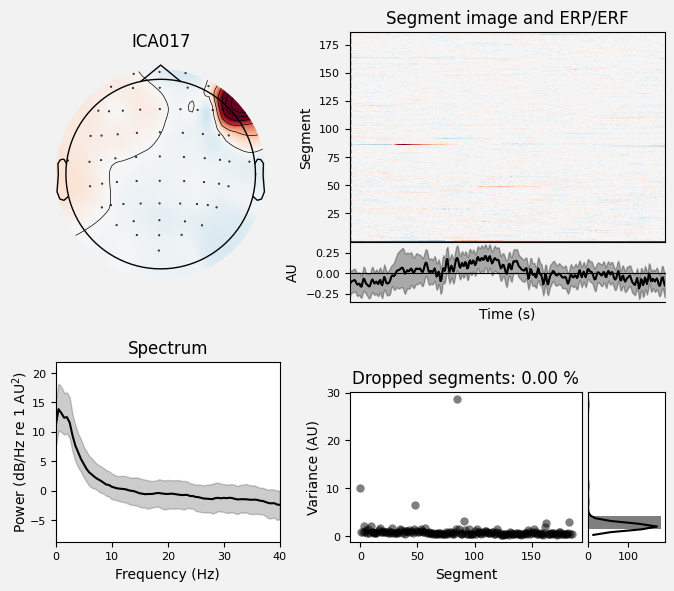

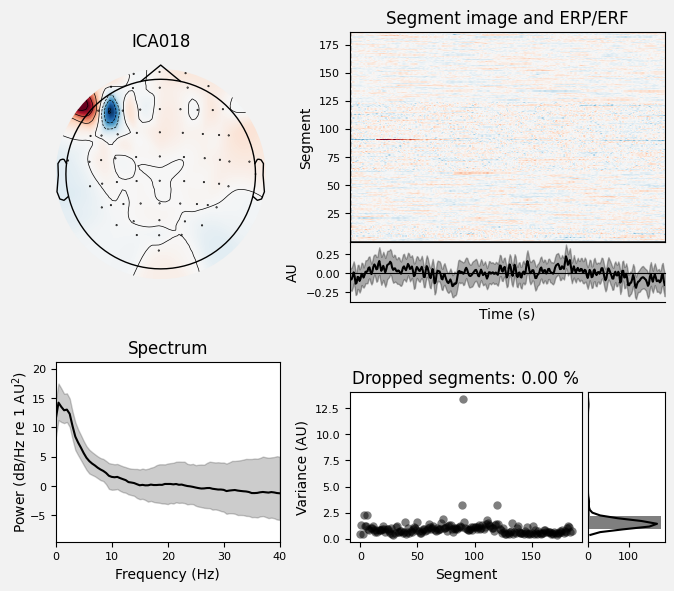

In [24]:
raw_clean, ica_info = pp.reject_ica_components(raw_ref, ica, apply=False)

print(f"EOG components flagged: {ica_info['eog_components']}")
print(f"Muscle components flagged: {ica_info['muscle_components']}")
print(f"Total to exclude: {ica.exclude}")

# Plot scores so we can see *why* each component was flagged
fig = ica.plot_scores(ica_info['eog_scores'], title="EOG correlation scores")

# Detailed view of each excluded component
for c in ica.exclude:
    ica.plot_properties(raw_ref, picks=c, psd_args={"fmax": 40});

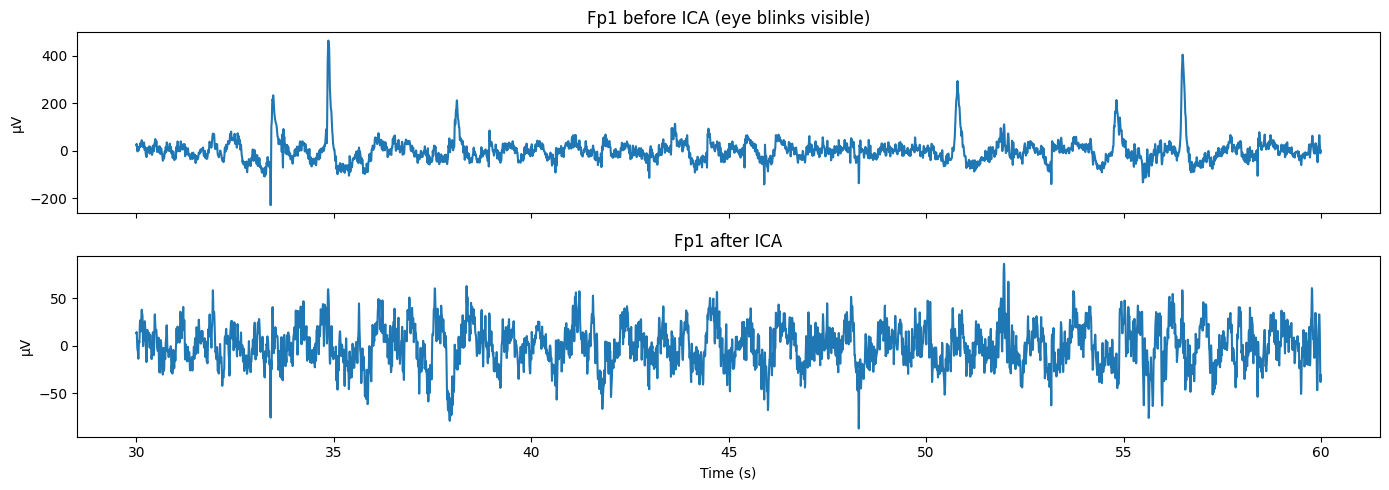

In [25]:
# Now actually apply
raw_clean = ica.apply(raw_ref.copy())

# Overlay Fp1 before and after — should see blinks visibly removed
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
window = slice(*raw_ref.time_as_index([30, 60]))
axes[0].plot(raw_ref.times[window],
             raw_ref.get_data(picks="Fp1")[0, window] * 1e6)
axes[0].set(title="Fp1 before ICA (eye blinks visible)", ylabel="µV")
axes[1].plot(raw_clean.times[window],
             raw_clean.get_data(picks="Fp1")[0, window] * 1e6)
axes[1].set(title="Fp1 after ICA", xlabel="Time (s)", ylabel="µV")
plt.tight_layout()

## Epoching

The EEGBCI runs encode events via annotations:
- **T0**: rest period
- **T1**: imagined left fist (in runs 4/8/12)
- **T2**: imagined right fist (in runs 4/8/12)

For binary classification we keep T1 and T2 and discard T0.

**Window: -0.5 to +4.0 s relative to cue onset.**
- 0 to 4 s covers the cued imagination period (the protocol's design).
- -0.5 to 0 s is the pre-cue baseline window.
- Total: 4.5 s × 160 Hz = 720 samples per trial — matches the planned
  feature-extraction dimensions.

**Baseline correction**: subtract the mean of the -0.5 to 0 s window from
each channel, per trial. Removes residual DC drift not caught by the 1 Hz
HPF and equalizes channels' starting points.

Expected trial count: ~30 per run × 3 runs = ~90 trials, before AutoReject.

<Epochs | 45 events (all good), -0.5 – 4 s (baseline -0.5 – 0 s), ~15.9 MiB, data loaded,
 np.str_('T1'): 23
 np.str_('T2'): 22>
Event distribution:
[3 2 2 3 3 2 3 2 3 2 2 3 2 3 2 2 3 2 3 2 3 2 3 3 2 2 3 3 2 2 3 2 3 2 2 3 3
 2 2 3 3 2 3 2 3]
Trials per class: {np.int64(2): np.int64(23), np.int64(3): np.int64(22)}


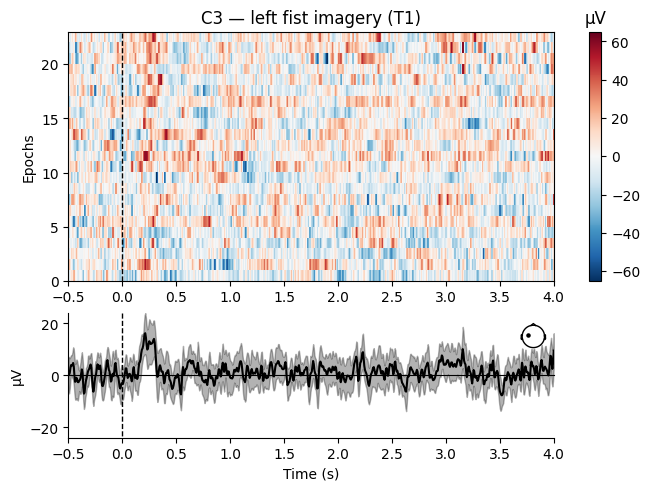

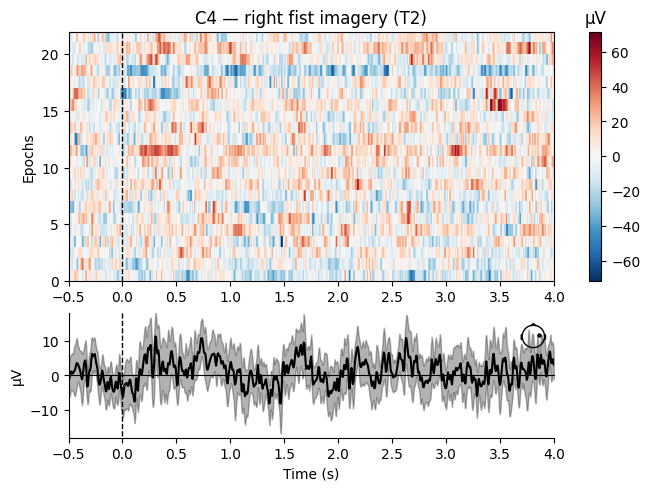

In [26]:
epochs = pp.epoch_data(raw_clean)
print(epochs)
print(f"Event distribution:\n{epochs.events[:, -1]}")
print(f"Trials per class: {dict(zip(*np.unique(epochs.events[:, -1], return_counts=True)))}")

# Visualize a few epochs from each class
epochs["T1"].plot_image(picks="C3", title="C3 — left fist imagery (T1)");
epochs["T2"].plot_image(picks="C4", title="C4 — right fist imagery (T2)");

## Auto-Reject Bad Epochs

ICA removed sources that were consistently present across the recording.
But individual epochs can still be contaminated by one-off events — a sudden
movement, a transient electrode pop — that ICA doesn't catch because they
don't form a coherent component.

**AutoReject** (Jas et al. 2017) learns per-channel peak-to-peak rejection
thresholds by cross-validation, then for each epoch decides whether to:
- accept it as-is,
- interpolate a small number of bad channels for that epoch only, or
- drop the epoch entirely (if too many channels are bad).

This is preferable to a single hand-picked global threshold like "reject
anything > 100 µV" because the right threshold varies by subject.

Before AutoReject: 45 epochs
After AutoReject:  45 epochs
Dropped: 45 retained, 0 dropped


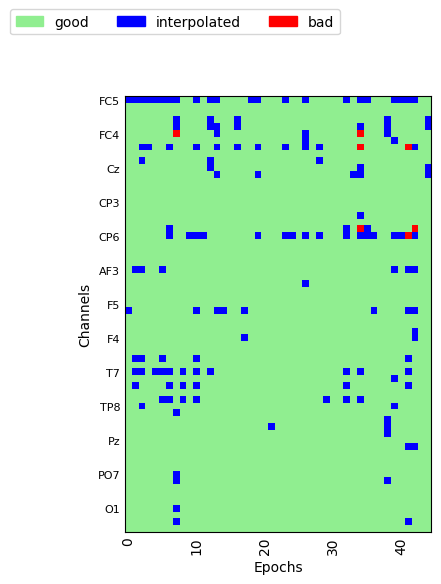

In [28]:
epochs_clean, reject_log = pp.autoreject_epochs(epochs)

print(f"Before AutoReject: {len(epochs)} epochs")
print(f"After AutoReject:  {len(epochs_clean)} epochs")
print(f"Dropped: {(~reject_log.bad_epochs).sum()} retained, "
      f"{reject_log.bad_epochs.sum()} dropped")

reject_log.plot("horizontal");

## Save Processed Data & Summary

The cleaned epochs are saved as `.fif` (MNE's native format) so notebook 03
can consume them with full metadata intact (channel positions, sampling
rate, event codes, annotations).

We also save a small JSON sidecar with preprocessing parameters and trial
counts — useful for the dashboard and for tracking what was done when we
scale to 109 subjects.

In [29]:
import json

out_dir = Path("../data/processed")
out_dir.mkdir(parents=True, exist_ok=True)

fif_path = out_dir / f"sub-{SUBJECT:03d}_epo.fif"
epochs_clean.save(fif_path, overwrite=True)

summary = {
    "subject": SUBJECT,
    "runs": list(RUNS),
    "n_channels": len(epochs_clean.ch_names),
    "n_bad_channels": len(bads),
    "bad_channel_names": bads,
    "n_ica_components_total": ica.n_components_,
    "n_ica_components_excluded": len(ica.exclude),
    "ica_excluded_indices": list(map(int, ica.exclude)),
    "n_epochs_initial": len(epochs),
    "n_epochs_after_autoreject": len(epochs_clean),
    "n_epochs_per_class": {
        str(k): int(v) for k, v in zip(*np.unique(epochs_clean.events[:, -1], return_counts=True))
    },
    "sampling_rate_hz": epochs_clean.info["sfreq"],
    "epoch_window_s": [-0.5, 4.0],
    "samples_per_epoch": epochs_clean.get_data().shape[-1],
}

with open(out_dir / f"sub-{SUBJECT:03d}_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

summary

{'subject': 1,
 'runs': [4, 8, 12],
 'n_channels': 64,
 'n_bad_channels': 0,
 'bad_channel_names': [],
 'n_ica_components_total': 20,
 'n_ica_components_excluded': 5,
 'ica_excluded_indices': [0, 15, 16, 17, 18],
 'n_epochs_initial': 45,
 'n_epochs_after_autoreject': 45,
 'n_epochs_per_class': {'2': 23, '3': 22},
 'sampling_rate_hz': 160.0,
 'epoch_window_s': [-0.5, 4.0],
 'samples_per_epoch': 721}

## Wrap-up

We took raw, contaminated EEG and produced ~80–90 clean epochs of 720
samples × 64 channels each, labeled by imagined-movement class. Each
preprocessing decision was driven by something concrete: an observation in
notebook 01, a property of the recording protocol, or an established
finding from the methods literature.

**Next:** notebook 03 (`03_features.ipynb`) consumes the saved `.fif` and
extracts band-power and CSP features for classical ML baselines.

**Open questions / future work** (for the methodology doc):
- Compare statistical vs `pyprep` bad-channel detection across all 109 subjects.
- Sensitivity analysis: how do classification scores change with HPF at 0.5
  vs 1.0 vs 2.0 Hz? With ICA components = 15 vs 20 vs 30?
- Some subjects in the dataset are known to have poor motor imagery performance
  (the "BCI illiteracy" effect). Does our pipeline preserve the signal in
  those subjects, or does AutoReject drop most of their epochs?